# Stochastic Uncertainty Around the LSTM Forecast

A point forecast gives one expected future yield curve. A probabilistic forecast asks: what are plausible yield curves around that point forecast?

This notebook uses validation residuals to build a simple uncertainty model and then reads the saved Monte Carlo outputs.

## Key terms

- **Yield curve**: the set of Treasury yields across maturities, from short-term bills to long-term bonds.
- **Maturity**: how long the Treasury security has until repayment, such as 3M, 2Y, or 30Y.
- **Point forecast**: one best estimate for the future yield at each maturity.
- **Residual**: actual change minus predicted change. This notebook uses past residuals as a rough guide to future forecast error.
- **Variance**: how spread out one maturity's errors are.
- **Covariance**: how two maturities' errors move together.
- **Covariance matrix**: a table containing all variances and covariances across maturities.
- **Multivariate normal distribution**: a probability model that samples several related maturity errors at once.
- **Monte Carlo simulation**: repeatedly sampling many possible future yield curves instead of relying on one forecast.
- **Probabilistic forecast**: a range of plausible outcomes around the point estimate.


## Assumptions

This is intentionally simple. The notebook treats validation residuals as a guide to near-future forecast errors, assumes those errors are centered at zero, samples them from a multivariate normal distribution, and keeps the same covariance matrix for this one-step forecast.

That means these ranges are model-based uncertainty estimates, not market-implied confidence intervals. They are useful for learning how forecast uncertainty changes across the curve.


In [1]:
# ruff: noqa: E402, I001
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SUMMARY_PATH = PROJECT_ROOT / "results" / "uncertainty_summary.json"
SCENARIO_PATH = PROJECT_ROOT / "results" / "monte_carlo_yield_curves.csv"
RANGE_PATH = PROJECT_ROOT / "reports" / "tables" / "uncertainty_ranges.csv"
FAN_FIGURE = PROJECT_ROOT / "reports" / "figures" / "yield_curve_fan.png"
RANGE_FIGURE = (
    PROJECT_ROOT / "reports" / "figures" / "uncertainty_ranges_by_maturity.png"
)
DISTRIBUTION_FIGURE = (
    PROJECT_ROOT / "reports" / "figures" / "monte_carlo_distribution_by_maturity.png"
)
SIMULATION_FIGURE = (
    PROJECT_ROOT / "reports" / "figures" / "monte_carlo_simulated_curves.png"
)

## Load saved uncertainty outputs

The simulation generated approximately 1,000 future yield curves and saved confidence ranges by maturity.

In [2]:
summary = json.loads(SUMMARY_PATH.read_text())
scenarios = pd.read_csv(SCENARIO_PATH)
ranges = pd.read_csv(RANGE_PATH)
run_overview = pd.DataFrame(
    [
        {
            "latest_input_date": summary["latest_input_date"],
            "scenario_count": summary["scenario_count"],
            "residual_source": summary["residual_source"],
            "scenario_rows": scenarios.shape[0],
            "scenario_columns": scenarios.shape[1],
        }
    ]
)
display(run_overview.style.hide(axis="index"))


latest_input_date,scenario_count,residual_source,scenario_rows,scenario_columns
2026-09-08,1000,validation split only,1000,8


## Residual covariance matrix

This matrix is estimated from validation residuals only. Values are in squared basis-point units. Larger diagonal values mean that maturity has more forecast-error variance. Positive off-diagonal values mean errors tend to move together.

In [3]:
maturities = list(summary["point_forecast_yields_percent"].keys())
covariance = pd.DataFrame(
    summary["residual_covariance_basis_points"],
    index=pd.Index(maturities, name="maturity"),
    columns=maturities,
)
display(covariance.style.format("{:.3f}"))


,3M,6M,1Y,2Y,5Y,10Y,30Y
maturity,,,,,,,
3M,6.190,3.290,2.389,2.375,2.250,2.062,1.695
6M,3.290,4.919,3.458,3.674,3.979,3.469,3.233
1Y,2.389,3.458,6.251,5.940,6.576,5.245,4.935
2Y,2.375,3.674,5.940,12.138,12.823,10.955,9.894
5Y,2.250,3.979,6.576,12.823,17.841,16.470,15.299
10Y,2.062,3.469,5.245,10.955,16.470,19.646,18.454
30Y,1.695,3.233,4.935,9.894,15.299,18.454,21.165


## Yield-curve fan

Start here for the big picture. The fan chart shows the model's point forecast across the whole yield curve, then wraps uncertainty bands around it.

The bands answer: if we move across maturities from 3M to 30Y, where does the full forecast curve have more or less uncertainty? A wider band means the simulated future curves are more spread out at that maturity.


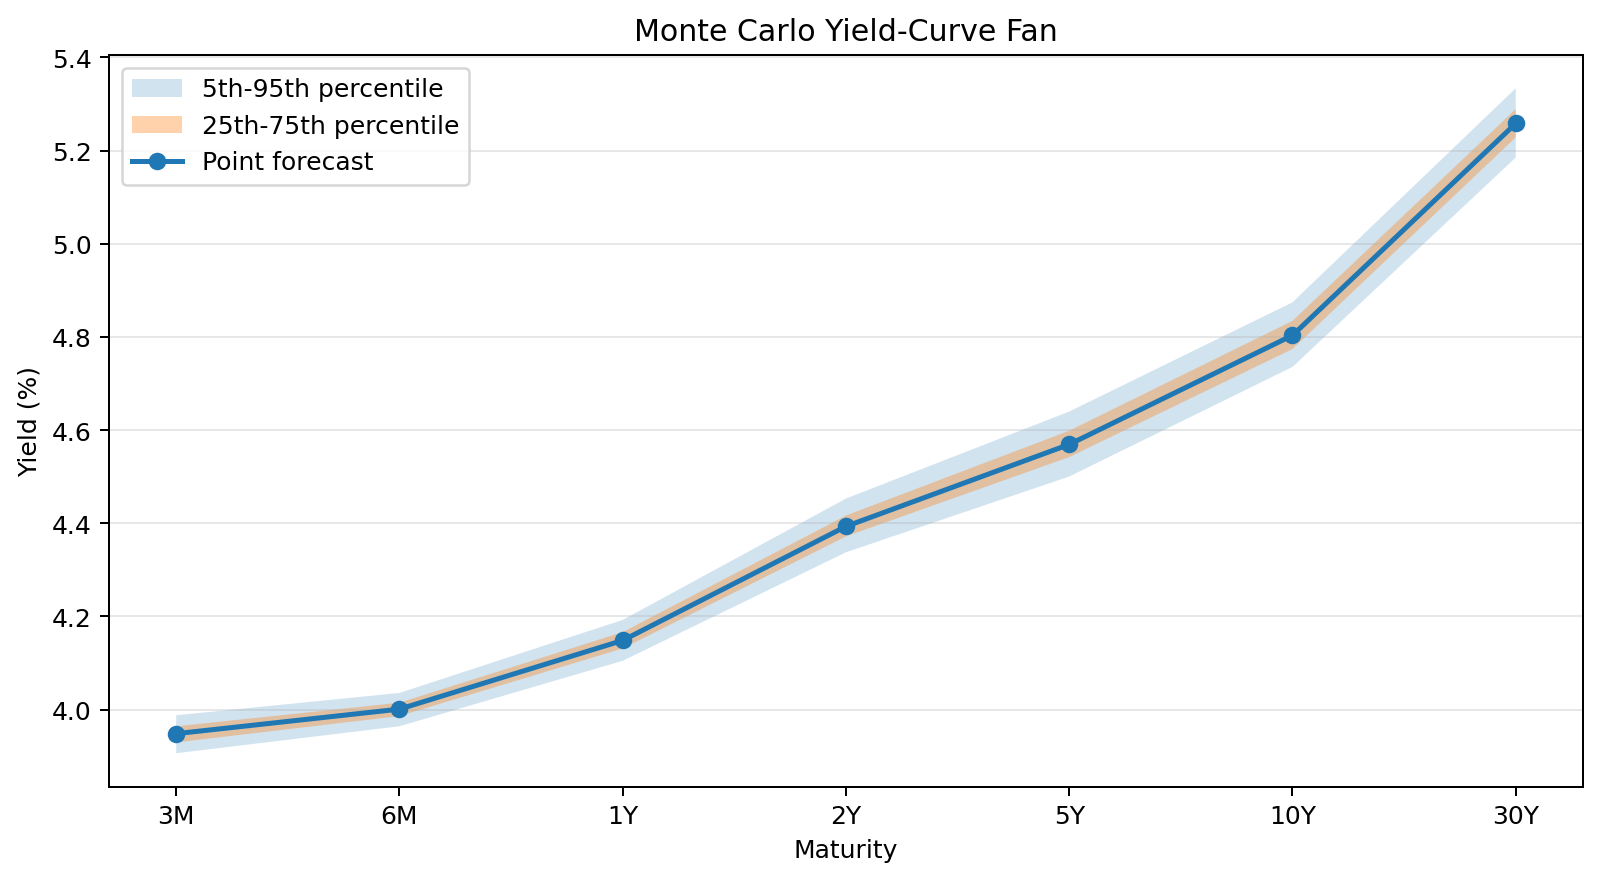

In [4]:
display(Image(filename=str(FAN_FIGURE)))

## Confidence ranges by maturity

This table is the numeric version of the uncertainty story. For each maturity, it shows the 5th, 50th, and 95th percentile simulated yield levels. The 90% width is measured in basis points.

Use this when you want exact numbers instead of reading them from a chart.


In [5]:
display(
    ranges.style.hide(axis="index").format(
        {
            "point_forecast_yield_percent": "{:.4f}",
            "p05_yield_percent": "{:.4f}",
            "p50_yield_percent": "{:.4f}",
            "p95_yield_percent": "{:.4f}",
            "width_90pct_bp": "{:.2f}",
        }
    )
)


maturity,point_forecast_yield_percent,p05_yield_percent,p50_yield_percent,p95_yield_percent,width_90pct_bp
3M,3.9485,3.9064,3.9470,3.9880,8.16
6M,4.0012,3.9643,4.0000,4.0359,7.16
1Y,4.1486,4.1049,4.1477,4.1927,8.78
2Y,4.3934,4.3378,4.3939,4.4531,11.54
5Y,4.5693,4.5004,4.5689,4.6399,13.95
10Y,4.8035,4.7357,4.8029,4.8744,13.87
30Y,5.2583,5.1851,5.2579,5.3338,14.87


### Percentile yield-curve graph

This graph uses the same percentile idea as the fan chart, but it is easier to compare maturity-by-maturity.

The fan chart is best for seeing the whole forecast curve at once. This percentile graph is best for asking: which maturity has the widest 5th-to-95th percentile range?


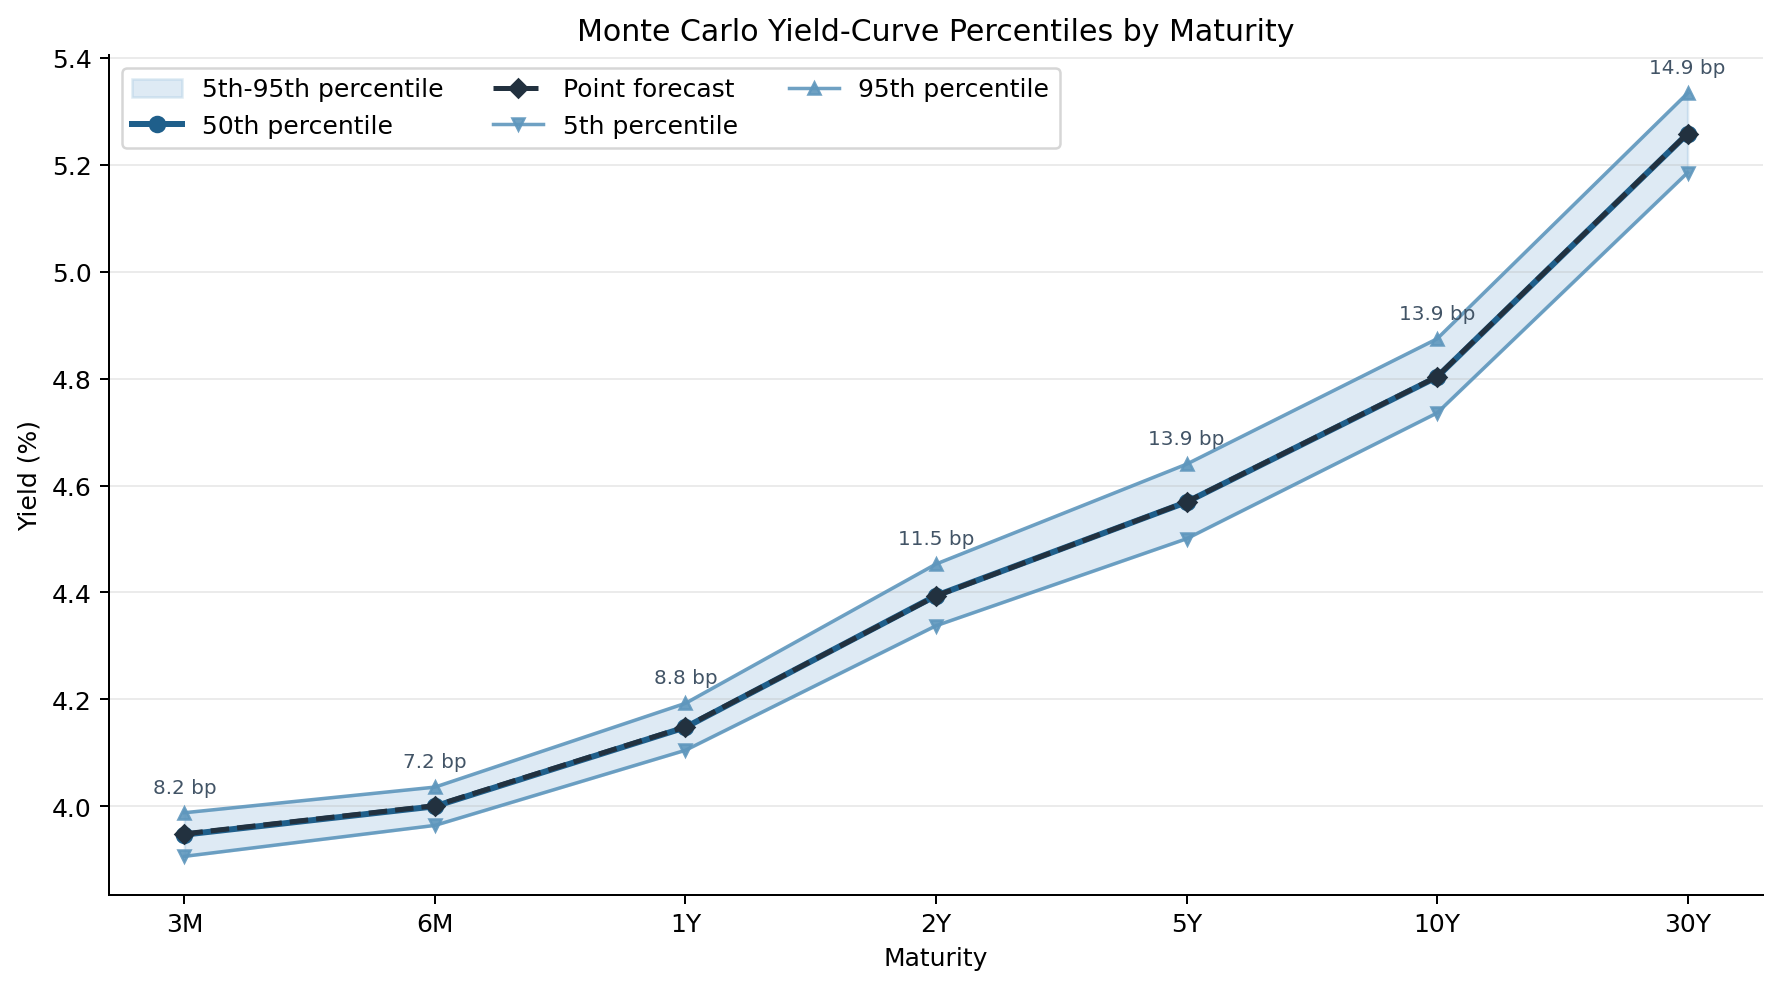

In [6]:
assert RANGE_FIGURE.exists(), RANGE_FIGURE
display(Image(filename=str(RANGE_FIGURE)))


## Example simulated curves

Each row is one simulated future yield curve. The first column is the scenario number, and the remaining columns are the simulated yields for each maturity.


In [8]:
display(scenarios.head(10).style.hide(axis="index").format(precision=4))


scenario,3M,6M,1Y,2Y,5Y,10Y,30Y
1,3.9562,4.0453,4.1568,4.3788,4.5554,4.7886,5.2347
2,3.9345,3.9975,4.1650,4.4100,4.5916,4.7997,5.2745
3,3.9754,4.0014,4.1424,4.3939,4.5497,4.7763,5.2303
4,3.9350,3.9860,4.1410,4.3967,4.6003,4.8456,5.2972
5,3.9700,4.0147,4.1207,4.3508,4.5394,4.7956,5.2653
6,3.9418,3.9709,4.1300,4.3717,4.5375,4.7501,5.2001
7,3.9532,3.9998,4.1595,4.4097,4.5959,4.8245,5.2978
8,3.9618,3.9995,4.1233,4.3878,4.5618,4.8147,5.2556
9,3.8985,3.9943,4.1407,4.3829,4.5852,4.8304,5.2782
10,3.9485,3.9854,4.1299,4.3540,4.5393,4.7951,5.2442


## Interpretation

The visuals answer related but different questions:

- The fan chart shows the overall forecast curve plus uncertainty bands.
- The confidence-range table and percentile graph make the 5th-to-95th percentile range easy to compare by maturity.
- The all-lines Monte Carlo graph shows every simulated yield curve before summarizing them into bands.

So yes, `FAN_FIGURE` and `RANGE_FIGURE` are related, but they are not redundant. The fan chart is the big-picture view. The range figure is the comparison view.

This is a lightweight uncertainty estimate, not a full market risk engine. Its value is that it turns one forecast into many plausible curves while preserving the observed cross-maturity error structure from validation residuals.
